In [2]:
import pertpy as pt
import anndata as ad

/Users/julessamara/Projects/IICD_2026_Group_Project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
adata = pt.dt.replogle_2022_k562_essential()

/Users/julessamara/Projects/IICD_2026_Group_Project/.venv/lib/python3.13/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

In [4]:
adata

AnnData object with n_obs × n_vars = 310385 × 8563
    obs: 'batch', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'guide_id', 'percent_mito', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'disease', 'cancer', 'cell_line', 'sex', 'age', 'perturbation', 'organism', 'perturbation_type', 'tissue_type', 'ncounts', 'ngenes', 'nperts', 'percent_ribo'
    var: 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'ensembl_id', 'ncounts', 'ncells'
    layers: None

In [5]:
adata.obs["perturbation"].value_counts()

perturbation
control    10691
RPL3        1996
NCBP2        992
KIF11        974
SLC39A9      752
           ...  
RFFL           7
POLR3A         6
POT1           5
RBM22          5
SEC62          5
Name: count, Length: 2058, dtype: int64

In [6]:
import scvi

scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

Seed set to 0


Last run with scvi-tools version: 1.3.3


In [7]:
ctrl_adata = adata[adata.obs["perturbation"] == "control"].copy()
ctrl_adata

AnnData object with n_obs × n_vars = 10691 × 8563
    obs: 'batch', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'guide_id', 'percent_mito', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'disease', 'cancer', 'cell_line', 'sex', 'age', 'perturbation', 'organism', 'perturbation_type', 'tissue_type', 'ncounts', 'ngenes', 'nperts', 'percent_ribo'
    var: 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'ensembl_id', 'ncounts', 'ncells'
    layers: None

In [8]:
scvi.model.SCVI.setup_anndata(
    ctrl_adata,
    categorical_covariate_keys=["batch"],
    continuous_covariate_keys=["percent_mito", "percent_ribo"],
)

In [9]:
model = scvi.model.SCVI(ctrl_adata, n_latent=32)

In [10]:
model

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 32, n_layers: 1, dropout_rate: 0.1, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: normal.
Training status: Not Trained
Model's adata is minified?: False

In [11]:
model.train(train_size=0.8, check_val_every_n_epoch=1, accelerator="mps")

/Users/julessamara/Projects/IICD_2026_Group_Project/.venv/lib/python3.13/site-packages/scvi/train/_trainrunner.py:69: UserWarning: `accelerator` has been set to `mps`. Please note that not all PyTorch/Jax operations are supported with this backend. as a result, some models might be slower and less accurate than usuall. Please verify your analysis!Refer to https://github.com/pytorch/pytorch/issues/77764 for more details.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/julessamara/Projects/IICD_2026_Group_Project/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, T

Epoch 400/400: 100%|██████████| 400/400 [04:38<00:00,  1.45it/s, v_num=1, train_loss_step=8.61e+3, train_loss_epoch=8.7e+3] 

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [04:38<00:00,  1.43it/s, v_num=1, train_loss_step=8.61e+3, train_loss_epoch=8.7e+3]


In [12]:
import matplotlib.pyplot as plt

hist = model.history


def plot_metric(train_key, val_key, title, ylabel):
    plt.figure(figsize=(6, 4))
    plt.plot(hist[train_key], label="train")
    plt.plot(hist[val_key], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

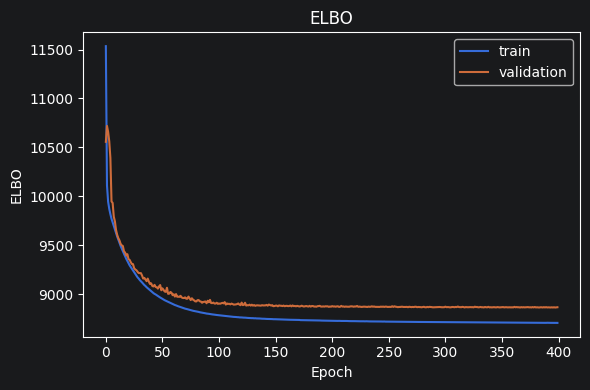

In [13]:
# Negative ELBO (Evidence lower bound)
if "elbo_train" in hist:
    plot_metric("elbo_train", "elbo_validation", "ELBO", "ELBO")

In [14]:
filtered_adata = ad.read_h5ad("../out/replogle_k562_filtered.h5ad")
filtered_adata

AnnData object with n_obs × n_vars = 308646 × 8563
    obs: 'batch', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'guide_id', 'percent_mito', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'disease', 'cancer', 'cell_line', 'sex', 'age', 'perturbation', 'organism', 'perturbation_type', 'tissue_type', 'ncounts', 'ngenes', 'nperts', 'percent_ribo'
    var: 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'ensembl_id', 'ncounts', 'ncells'
    uns: 'log1p'
    layers: None

In [15]:
raw_filtered_adata = adata[filtered_adata.obs_names].copy()

In [16]:
filtered_adata.obsm["X_scvi"] = model.get_latent_representation(raw_filtered_adata)

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


In [17]:
filtered_adata.write_h5ad("../out/replogle_k562_filtered_scvi.h5ad")